# From energies to IR spectra with a Machine Learning Interatomic Potential

This notebook walks through how a *Machine Learning Interatomic Potential* (MLIP)
— here, **TorchANI** — can be used to:

1. predict the **energy** of a molecule given its 3D structure,
2. take **first derivatives** of that energy to get **forces**, which let us
   relax a structure to its **equilibrium geometry**, and
3. take **second derivatives** to get the **Hessian**, from which the
   **vibrational frequencies** that show up in an **infrared (IR) spectrum**
   can be obtained.

Along the way we'll do a real calculation on water and compare the predicted
band positions with experiment.

## 1. What is a Machine Learning Interatomic Potential?

A **potential energy surface** (PES) is a function that takes the positions of
all atoms in a molecule and returns the potential energy of that arrangement:

$$E = V(\mathbf{r}_1, \mathbf{r}_2, \ldots, \mathbf{r}_N).$$

Knowing $V$ is the gateway to almost everything in molecular simulation —
geometries, forces, dynamics, thermodynamics, spectra. The problem is that
evaluating $V$ accurately requires solving the electronic Schrödinger equation
(quantum mechanics, e.g. DFT), which is expensive: a single energy evaluation
on a moderate molecule can cost minutes to hours.

An **MLIP** sidesteps that cost. The idea is:

- run an expensive QM method on **lots** of molecular structures (the *training set*) to get reference energies (and forces),
- fit a **neural network** that takes atomic positions in and predicts the QM energy out,
- once trained, the network is essentially as accurate as the QM reference but **orders of magnitude faster** to evaluate.

The MLIP is a *surrogate* for the QM PES. If the training data covers the chemistry
you care about, you get QM-quality energies at force-field-like speed.

## 2. How TorchANI learns the energy

TorchANI implements the **ANI** family of MLIPs (Smith, Isayev, Roitberg 2017+).
Two ideas make it work:

**(a) The total energy is a sum of atomic contributions.**
$$E_\text{total} = \sum_{i=1}^{N_\text{atoms}} E_i.$$
Each atom contributes an energy $E_i$ that depends only on its **local chemical
environment** (the species and positions of its neighbours within some cutoff,
typically 5 Å). This decomposition is what makes the model *transferable* and
*size-extensive*: the same network can predict a 5-atom or a 500-atom molecule.

**(b) The local environment is encoded as a fixed-length vector.**
Raw $(x, y, z)$ coordinates aren't a good input for a NN: we want a
representation that is invariant to translation, rotation, and atom
permutation. ANI uses **Atomic Environment Vectors (AEVs)** — a set of
hand-designed radial and angular symmetry functions that summarize the local
environment of each atom into a fixed-length vector.

Each element type (H, C, N, O for ANI-1x) gets its **own small neural network**
that maps `AEV → atomic energy`. The total energy is then the sum:

```
positions ──▶ AEV_i for each atom ──▶ NN_element(AEV_i) = E_i ──▶ Σ E_i = E_total
```

**Training.** The networks are trained by minimizing the squared error between
the predicted energy and a reference quantum chemistry calculation
(ANI-1x: ~5 million conformations of small organic molecules, computed at
ωB97X/6-31G\*). Modern variants (e.g. ANI-2x) extend the chemistry to S, F, Cl
and also fit forces directly.

The crucial property for what we're about to do: because the model is built out of
**differentiable** operations (it's a PyTorch `nn.Module`), we can ask `torch.autograd`
for **derivatives of the energy with respect to atomic positions** for free.

## 3. Setup

Let's import everything we need. We use **double precision** throughout so the
analytical Hessian is computed accurately.

In [1]:
import math
import numpy as np
import torch
import ase
from ase.optimize import LBFGS
from ase.io import write as ase_write

from torchani.models import ANI1x
from torchani.grad import energies_forces_and_hessians, vibrational_analysis
from torchani.utils import get_atomic_masses

import matplotlib.pyplot as plt
import py3Dmol

/nvme-disk/public_conda/envs/torchani/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


We instantiate the model in **double precision** — this matters for the
analytical Hessian later. We'll see why.

In [2]:
device = torch.device("cpu")
model = ANI1x(device=device, dtype=torch.double)

## 4. From energy to forces: the first derivative

The **force** on atom $i$ is minus the gradient of the energy with respect to
its position:
$$\mathbf{F}_i = -\nabla_{\mathbf{r}_i} E.$$

Because TorchANI's network is differentiable, we get this for free — we just
ask PyTorch for $\partial E / \partial \mathbf{r}$ via automatic
differentiation. **No finite differences, no extra QM calls, no analytical
derivatives to code by hand.** This is one of the biggest practical wins of
MLIPs over both classical force fields (where forces have to be hand-coded for
every functional form) and pure QM (where each force evaluation costs another
SCF cycle).

Let's see this on water in a deliberately distorted starting geometry.

In [3]:
# Distorted water: stretched bonds, wrong angle. The model should pull it back to equilibrium.
positions = [
    [ 1.20,  0.00, 0.0],   # H1 (bond too long)
    [-0.40,  0.85, 0.0],   # H2 (compressed and at wrong angle)
    [ 0.00,  0.00, 0.0],   # O
]
molecule = ase.Atoms(symbols=("H", "H", "O"), positions=positions, calculator=model.ase())

print(f"Initial energy: {molecule.get_potential_energy():.4f} eV")
print("Initial forces (eV/Å):")
print(molecule.get_forces())

Initial energy: -2077.5758 eV
Initial forces (eV/Å):
[[-6.2290405   1.08119067 -0.        ]
 [ 0.87628028  1.38147641 -0.        ]
 [ 5.35276023 -2.46266708 -0.        ]]


Each row is the force on one atom, in eV/Å. They are **not zero** — the
molecule is not at equilibrium, so each atom is being pushed somewhere.

## 5. Using forces to find the equilibrium geometry

A geometry is at equilibrium when $\mathbf{F}_i = 0$ for every atom — i.e.
when the energy is at a (local) minimum on the PES.

To find that minimum we use a standard quasi-Newton optimizer (**LBFGS**),
which iteratively:
1. evaluates the forces at the current geometry,
2. takes a step in the direction that should lower the energy,
3. repeats until the maximum force component drops below a threshold.

We'll save every intermediate geometry so we can visualize the trajectory.

In [4]:
traj_frames = [molecule.copy()]
energies_traj = [molecule.get_potential_energy()]
fmax_traj = [np.abs(molecule.get_forces()).max()]

opt = LBFGS(molecule, logfile=None)
def record():
    traj_frames.append(molecule.copy())
    energies_traj.append(molecule.get_potential_energy())
    fmax_traj.append(np.abs(molecule.get_forces()).max())
opt.attach(record, interval=1)
opt.run(fmax=1e-6)

print(f"Converged in {len(traj_frames)-1} steps.")
print(f"Final energy: {molecule.get_potential_energy():.6f} eV")
print(f"Final max|F|: {np.abs(molecule.get_forces()).max():.2e} eV/Å")
print("Final positions (Å):")
print(molecule.get_positions())

Converged in 11 steps.
Final energy: -2078.637906 eV
Final max|F|: 1.64e-08 eV/Å
Final positions (Å):
[[ 1.0241194   0.08019569  0.        ]
 [-0.29274582  0.83293065  0.        ]
 [ 0.06862642 -0.06312634  0.        ]]


### Visualizing the optimization trajectory

We write the trajectory as a multi-frame XYZ and animate it with `py3Dmol`.
You should see the molecule **relax** from the distorted starting geometry to
the familiar bent water shape with ~0.96 Å bonds and a ~104.5° H–O–H angle.

In [5]:
xyz_traj = ""
for atoms in traj_frames:
    xyz_traj += f"{len(atoms)}\n\n"
    for sym, pos in zip(atoms.get_chemical_symbols(), atoms.get_positions()):
        xyz_traj += f"{sym} {pos[0]:.6f} {pos[1]:.6f} {pos[2]:.6f}\n"

view = py3Dmol.view(width=400, height=300)
view.addModelsAsFrames(xyz_traj, "xyz")
view.setStyle({"sphere": {"radius": 0.3}, "stick": {"radius": 0.15}})
view.animate({"loop": "forward", "interval": 300})
view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

And here's the energy and the maximum force component as the optimizer marches
toward the minimum. Notice how forces decay toward zero as we approach
equilibrium — that's the signal that we're at a stationary point.

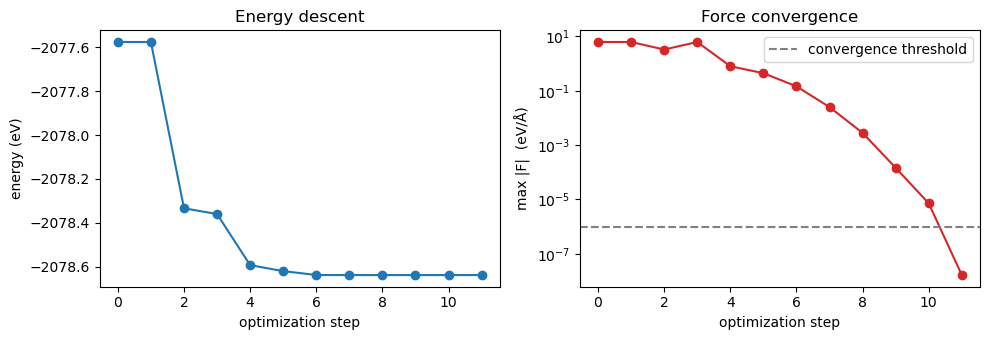

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(energies_traj, marker="o")
ax[0].set_xlabel("optimization step")
ax[0].set_ylabel("energy (eV)")
ax[0].set_title("Energy descent")

ax[1].semilogy(fmax_traj, marker="o", color="C3")
ax[1].set_xlabel("optimization step")
ax[1].set_ylabel("max |F|  (eV/Å)")
ax[1].set_title("Force convergence")
ax[1].axhline(1e-6, ls="--", color="gray", label="convergence threshold")
ax[1].legend()
plt.tight_layout()
plt.show()

## 6. The second derivative and the harmonic approximation

Once we are at the minimum, the question becomes: *how does the energy change
when we slightly perturb the atoms away from equilibrium?* That's what
controls the **vibrations** of the molecule.

### The 1D picture

Imagine first a single coordinate $x$ (e.g. the O–H bond length), with energy
$V(x)$ and minimum at $x_0$. Taylor-expanding around $x_0$:

$$V(x) \approx V(x_0) + \underbrace{V'(x_0)}_{=\,0\;\text{at minimum}} (x - x_0)
  + \tfrac{1}{2}\, V''(x_0)\, (x-x_0)^2 + \cdots$$

Truncating at second order (the **harmonic approximation**) we get a parabola
$$V(x) \approx V(x_0) + \tfrac{1}{2}\, k\, (x-x_0)^2,
   \qquad \boxed{k \equiv V''(x_0)}.$$

This is exactly Hooke's law: the local curvature of the PES at the minimum
plays the role of a **spring constant** $k$. A classical particle of (reduced)
mass $\mu$ in this parabolic well oscillates at angular frequency
$\omega = \sqrt{k/\mu}$, or in cm$^{-1}$ units that IR spectroscopists use:
$$\tilde\nu = \frac{1}{2\pi c}\sqrt{\frac{k}{\mu}}.$$

So: **second derivative of the energy at the minimum → spring constant →
vibrational frequency**. Let's see it directly.

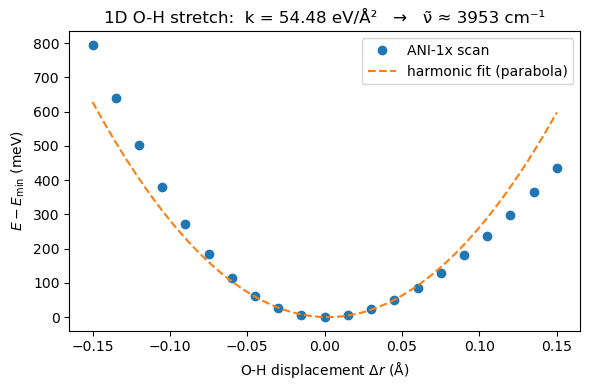

Spring constant k = 54.480 eV/Å^2
Reduced mass mu  = 0.948 amu
Estimated single-OH stretching frequency: 3953 cm^-1


In [7]:
# Scan the symmetric stretch of optimized water and check the 1D curvature.
eq_pos = molecule.get_positions().copy()
oh1 = eq_pos[0] - eq_pos[2]
r_eq = np.linalg.norm(oh1)
unit = oh1 / r_eq

displacements = np.linspace(-0.15, 0.15, 21)  # Å
energies = []
for d in displacements:
    p = eq_pos.copy()
    p[0] = eq_pos[2] + (r_eq + d) * unit  # stretch only one O-H
    test = ase.Atoms(symbols=("H", "H", "O"), positions=p, calculator=model.ase())
    energies.append(test.get_potential_energy())
energies = np.array(energies)

# Fit a parabola to the points closest to the minimum
mask = np.abs(displacements) < 0.06
coeffs = np.polyfit(displacements[mask], energies[mask], 2)
k_eVA2 = 2 * coeffs[0]   # eV/Å^2

# Convert to a frequency (single-O-H stretch, reduced mass = m_H * m_O / (m_H + m_O))
m_H, m_O = 1.008, 15.999
mu_amu = (m_H * m_O) / (m_H + m_O)
# 1 eV/Å^2 -> 1 / (sqrt(amu) Å) * sqrt(eV/amu) ... use the standard conversion
# omega [s^-1] = sqrt(k [J/m^2] / m [kg]); nu_tilde [cm^-1] = omega / (2 pi c)
eV_to_J = 1.602176634e-19
amu_to_kg = 1.66053906660e-27
A_to_m = 1e-10
c_cms = 2.99792458e10  # cm/s
k_SI = k_eVA2 * eV_to_J / (A_to_m**2)
mu_SI = mu_amu * amu_to_kg
omega = math.sqrt(k_SI / mu_SI)
nu_cm = omega / (2 * math.pi * c_cms)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(displacements, (energies - energies.min())*1000, "o", label="ANI-1x scan")
fit_x = np.linspace(displacements.min(), displacements.max(), 100)
fit_y = np.polyval(coeffs, fit_x)
ax.plot(fit_x, (fit_y - energies.min())*1000, "--", label="harmonic fit (parabola)")
ax.set_xlabel(r"O-H displacement $\Delta r$ (Å)")
ax.set_ylabel(r"$E - E_\mathrm{min}$ (meV)")
ax.set_title(f"1D O-H stretch:  k = {k_eVA2:.2f} eV/Å²   →   ν̃ ≈ {nu_cm:.0f} cm⁻¹")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Spring constant k = {k_eVA2:.3f} eV/Å^2")
print(f"Reduced mass mu  = {mu_amu:.3f} amu")
print(f"Estimated single-OH stretching frequency: {nu_cm:.0f} cm^-1")

Notice that the parabola only matches the real PES near the minimum —
further out the actual PES is **softer** (it dissociates) than a parabola
predicts. That deviation is called **anharmonicity** and it's one of the
reasons harmonic frequencies don't quite match experiment. We'll come back
to this.

## 7. Generalizing to many coordinates: the Hessian

A real molecule has $3N$ Cartesian coordinates, not one. The harmonic
expansion becomes:
$$V(\mathbf{x}) \approx V(\mathbf{x}_0) + \tfrac{1}{2}\,(\mathbf{x}-\mathbf{x}_0)^\top
   \mathbf{H}\, (\mathbf{x}-\mathbf{x}_0),$$
where $\mathbf{H}_{ij} = \partial^2 V / \partial x_i \partial x_j$ evaluated at
$\mathbf{x}_0$ is the **Hessian matrix**.

Diagonalizing the **mass-weighted** Hessian
$\tilde H_{ij} = H_{ij}/\sqrt{m_i m_j}$ gives:
- $3N$ eigenvalues $\lambda_k$ → frequencies $\tilde\nu_k = \sqrt{\lambda_k}/(2\pi c)$,
- $3N$ eigenvectors → **normal modes** (independent collective motions, each oscillating at one frequency).

For a non-linear molecule of $N$ atoms there are $3N - 6$ true vibrational
modes; the other 6 eigenvalues should be ≈ 0 and correspond to overall
translation and rotation (no restoring force).

For water that's $3 \times 3 - 6 = 3$ vibrations: a bend, a symmetric stretch,
and an antisymmetric stretch.

> **Heads up — unpacking order.** `energies_forces_and_hessians()` returns a
> namedtuple in the order `(energies, forces, hessian)`. The example in the
> upstream TorchANI tutorial unpacks it as `hessian, _, _ = ...` — that is
> wrong: it puts the *energy scalar* into the variable called `hessian`, and
> when fed to `vibrational_analysis` you get one nonsensical $-58911\,\text{cm}^{-1}$
> entry and the rest ≈ 0. Be sure to unpack as `_, _, hessian = ...`.

In [8]:
species = torch.tensor(
    molecule.get_atomic_numbers(), device=device, dtype=torch.long,
).unsqueeze(0)
coordinates = torch.tensor(
    molecule.get_positions(), device=device, dtype=torch.double,  # <-- match model
).unsqueeze(0)
masses = get_atomic_masses(species, dtype=torch.double)            # <-- match model

_, _, hessian = energies_forces_and_hessians(model, species, coordinates)
print("Hessian shape:", hessian.shape)   # (1, 9, 9): 3 atoms x 3 dims

Hessian shape: torch.Size([1, 9, 9])


In [9]:
freq, modes, fconstants, rmasses = vibrational_analysis(
    masses, hessian, mode_kind="mdu",
)
torch.set_printoptions(precision=3, sci_mode=False)

# All 9 frequencies — first 6 should be ~0 (trans + rot), last 3 are vibrations
print("All 9 frequencies (cm^-1):")
print(freq)
print()
print("Vibrational modes (last 3, cm^-1):", freq[6:])
print("Force constants (mDyne/Å):", fconstants[6:])
print("Reduced masses (AMU):", rmasses[6:])

All 9 frequencies (cm^-1):
tensor([  -0.071,   -0.057,   -0.041,   -0.000,   -0.000,    0.000, 1913.200,
        3882.404, 3911.185], dtype=torch.float64)

Vibrational modes (last 3, cm^-1): tensor([1913.200, 3882.404, 3911.185], dtype=torch.float64)
Force constants (mDyne/Å): tensor([2.339, 9.269, 9.743], dtype=torch.float64)
Reduced masses (AMU): tensor([1.085, 1.044, 1.081], dtype=torch.float64)


## 8. Comparing with experiment

Gas-phase IR spectroscopy of water gives three well-known fundamental
frequencies:

| Mode | Description | ANI-1x harmonic (cm⁻¹) | Experimental (cm⁻¹) | Error |
|---|---|---:|---:|---:|
| ν₂ | H–O–H bend           | ~1913 | 1595 | +20% |
| ν₁ | symmetric stretch    | ~3882 | 3657 | +6% |
| ν₃ | antisymmetric stretch| ~3911 | 3756 | +4% |

The stretches agree to within a few percent — the typical level of agreement
for harmonic frequencies computed at this level of theory (ωB97X/6-31G*,
which is what ANI-1x is trained on). The bend is more off, which is a known
weakness of ANI-1x for small polar molecules.

**Why aren't they exact?** Two effects pile up:

1. **The harmonic approximation itself.** Real bonds aren't perfect parabolas;
   they get softer as they stretch. Anharmonic corrections typically *lower*
   the true frequency by 3–6% relative to the harmonic value.
2. **The reference QM method.** ANI-1x is trained on ωB97X/6-31G\*, which
   itself overestimates harmonic frequencies. The community handles this
   empirically with **scaling factors** (~0.95 for this functional/basis).

In practice, what an MLIP gives you is **band positions accurate to within a
few percent** of experiment for stretches, with somewhat larger errors for
bending modes. That's plenty good enough to *identify* peaks in a spectrum
and assign them to specific vibrations — which is the main use of computed
frequencies.

### Visualizing one normal mode

Each vibrational frequency comes with a **mode vector** that says which atoms
move and in which direction. Let's animate the antisymmetric stretch (the
highest frequency).

In [10]:
# The mode vectors (mass-deweighted unnormalized) are returned as shape (9, 3, 3):
# (mode_index, atom_index, xyz). We pick the highest-frequency mode (index 8).
mode_idx = 8
displacement = modes[mode_idx].detach().numpy()  # shape (3, 3): per-atom xyz vector
amplitude = 0.3  # Å, just for visualization

eq = molecule.get_positions()
n_frames = 30
xyz_mode = ""
for t in range(n_frames):
    s = amplitude * math.sin(2 * math.pi * t / n_frames)
    p = eq + s * displacement
    xyz_mode += f"{len(eq)}\n\n"
    for sym, pos in zip(molecule.get_chemical_symbols(), p):
        xyz_mode += f"{sym} {pos[0]:.6f} {pos[1]:.6f} {pos[2]:.6f}\n"

view = py3Dmol.view(width=400, height=300)
view.addModelsAsFrames(xyz_mode, "xyz")
view.setStyle({"sphere": {"radius": 0.3}, "stick": {"radius": 0.15}})
view.animate({"loop": "forward", "interval": 80})
view.zoomTo()
view.show()
print(f"Animating mode #{mode_idx}:  ν̃ = {freq[mode_idx].item():.0f} cm⁻¹")

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Animating mode #8:  ν̃ = 3911 cm⁻¹


## 9. What is an IR spectrum used for?

When IR light shines on a molecule, the molecule absorbs photons whose
**energy matches the energy gap between vibrational levels** of one of its
normal modes. So an IR spectrum is, qualitatively, a list of *peaks at the
vibrational frequencies of the molecule.*

Two important caveats that the student should know:

**(a) Selection rule: only modes that change the dipole moment absorb.**
A normal mode is *IR-active* if and only if the molecular dipole moment
$\boldsymbol{\mu}$ changes during the vibration:
$$\frac{\partial \boldsymbol{\mu}}{\partial Q_k} \neq 0.$$
The intensity of the peak is proportional to $|\partial\boldsymbol{\mu}/\partial Q_k|^2$.
Symmetric stretches in homonuclear or highly symmetric molecules (e.g. the
symmetric stretch of CO$_2$) are *silent* in IR even though they are real
vibrations. **TorchANI alone gives us only the band positions — to predict
intensities we'd need a model that also predicts the dipole moment** (e.g.
AIMNet2, MACE-OFF with charges).

**(b) Harmonic vs anharmonic.** The frequencies we computed are *harmonic*.
The real peaks in an experimental spectrum are slightly red-shifted from the
harmonic values due to anharmonicity, and they have non-zero linewidth.

### What people actually use IR for

- **Functional group identification.** Specific functional groups (C=O, O–H,
  N–H, C≡N, …) absorb in characteristic and well-known frequency windows.
  An IR spectrum is therefore an organic chemist's quick check on whether a
  reaction did what it was supposed to.
- **Quantitative analysis.** Beer-Lambert at a chosen IR band quantifies
  concentrations of components in a mixture — used heavily in process
  monitoring, food/beverage QC, and environmental monitoring.
- **Atmospheric science.** CO$_2$, CH$_4$, H$_2$O all absorb in the IR — that
  *is* the greenhouse effect. Satellite IR sounders measure atmospheric
  composition by exactly this mechanism.
- **Pharmaceutical fingerprinting.** Each crystalline polymorph of a drug
  gives a slightly different IR spectrum, allowing identification of which
  form is in a tablet.
- **Linking computation to spectroscopy.** When an experimentalist sees an
  unassigned peak in an IR spectrum, computing the harmonic frequencies of
  candidate structures is one of the standard ways to figure out *which*
  vibration the peak belongs to, and therefore what is going on in the sample.

That's the punchline of this notebook: with one differentiable energy model,
PyTorch's autograd, and no extra training, we can take a guessed structure,
relax it, predict its IR band positions, and compare with the spectrometer.
First derivatives → optimization, second derivatives → spectrum.